# Evaluation Results Analysis (Merged)

这个 notebook 合并了 `eval_results_v2.jsonl` 和 `evalv2_results_v2.jsonl`，在完整数据与筛选后的高信息量 query 上分别展开多维度的分析与可视化。

In [1]:
# 该单元加载依赖、路径和通用工具函数
from pathlib import Path
import json
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

import matplotlib.font_manager as fm
warnings.filterwarnings('ignore')
PREFERRED_CHINESE_FONTS = ["PingFang SC", "Microsoft YaHei", "SimHei", "STHeiti", "Noto Sans CJK SC"]
available = [f.name for f in fm.fontManager.ttflist if any(pref in f.name for pref in PREFERRED_CHINESE_FONTS)]
if available:
    plt.rcParams['font.family'] = available + ['sans-serif']
    plt.rcParams['font.sans-serif'] = available + ['sans-serif']
else:
    plt.rcParams['font.family'] = ['sans-serif']
plt.rcParams['axes.unicode_minus'] = False

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid")
except ImportError:
    sns = None

BASE_DIR = Path('.')
FILE_A = BASE_DIR / 'eval_results_v2.jsonl'
FILE_B = BASE_DIR / 'evalv2_results_v2.jsonl'
MERGED_JSONL = BASE_DIR / 'eval_merged_v2.jsonl'

# 正则用于统计中文字符
CH_RE = re.compile(r'[一-鿿]')
LOW_INFO_QUERIES = {'嗯', '嗯嗯', '呃', '呃嗯', '额', '哦', '哦哦', '好', '好的', '行', '可以', '是的'}

def chinese_char_count(text):
    if not isinstance(text, str):
        return 0
    return len(CH_RE.findall(text))

def is_low_info_query(text):
    if not isinstance(text, str):
        return True
    t = text.strip()
    if not t:
        return True
    if t in LOW_INFO_QUERIES:
        return True
    if all(ch in '嗯哦呃额' for ch in t):
        return True
    return False

def plot_hist(series, title, bins=30):
    clean = series.dropna()
    if clean.empty:
        print(f'提示：{title} 没有可用数据，跳过绘图。')
        return
    plt.figure(figsize=(6, 3))
    if sns:
        sns.histplot(clean, bins=bins, kde=True)
    else:
        plt.hist(clean, bins=bins)
    plt.title(title)
    plt.tight_layout()
    plt.show()

def plot_box(data, cols, title):
    subset = data[cols]
    if subset.dropna(how='all').empty:
        print(f'提示：{title} 对应列无有效数据，跳过绘图。')
        return
    plt.figure(figsize=(6, 3))
    if sns:
        sns.boxplot(data=subset, orient='h')
    else:
        plt.boxplot([subset[c].dropna() for c in cols], labels=cols, vert=False)
    plt.title(title)
    plt.tight_layout()
    plt.show()

import time
RUN_ID = time.strftime('%Y%m%d_%H%M%S')
REPORTS_DIR = BASE_DIR / 'reports'
REPORTS_DIR.mkdir(exist_ok=True)
REPORT_ASSETS_DIR = REPORTS_DIR / f'report_assets_{RUN_ID}'
REPORT_ASSETS_DIR.mkdir(exist_ok=True)

## 数据加载与分群

该单元分别展示如何加载两个原始 JSONL，放在一起后再筛选 query 满足 4 个中文字符以上，且不是类似“嗯/嗯嗯”这种无信息填充的语句。

In [2]:
# 该单元加载两个 JSONL 并合并，再按 query 信息量分群
def load_jsonl(path):
    rows = []
    if not path.exists():
        raise FileNotFoundError(f'缺少文件: {path}')
    with path.open('r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                rows.append(json.loads(line))
            except json.JSONDecodeError:
                continue
    return pd.DataFrame(rows)

def attach_source(dataframe, source_name):
    df_local = dataframe.copy()
    df_local['_source_file'] = source_name
    return df_local

def extract_judge_winner(judge):
    if not isinstance(judge, dict):
        return None
    return judge.get('overall', {}).get('winner')

def extract_critical_points_count(judge):
    if not isinstance(judge, dict):
        return 0
    return len(judge.get('critical_points', []) or [])

def extract_useless_ratio(judge, side):
    if not isinstance(judge, dict):
        return np.nan
    payload = judge.get('useless_ratio', {}).get(side)
    if not isinstance(payload, dict):
        return np.nan
    return payload.get('ratio_0_100')

def safe_div(numerator, denominator):
    try:
        if denominator in (0, None) or (isinstance(denominator, float) and np.isnan(denominator)):
            return np.nan
        return numerator / denominator
    except Exception:
        return np.nan

if MERGED_JSONL.exists():
    df = load_jsonl(MERGED_JSONL)
    if '_source_file' not in df.columns:
        df_a = attach_source(load_jsonl(FILE_A), FILE_A.name)
        df_b = attach_source(load_jsonl(FILE_B), FILE_B.name)
        df = pd.concat([df_a, df_b], ignore_index=True)
else:
    df_a = attach_source(load_jsonl(FILE_A), FILE_A.name)
    df_b = attach_source(load_jsonl(FILE_B), FILE_B.name)
    df = pd.concat([df_a, df_b], ignore_index=True)
    if not df.empty:
        with MERGED_JSONL.open('w', encoding='utf-8') as f:
            for row in df.to_dict(orient='records'):
                f.write(json.dumps(row, ensure_ascii=False) + '\n')

if 'judge_overall_winner' not in df.columns:
    df['judge_overall_winner'] = df.get('judge').apply(extract_judge_winner)

if 'critical_points_count' not in df.columns:
    df['critical_points_count'] = df.get('judge').apply(extract_critical_points_count)

if 'useless_ratio_A' not in df.columns:
    df['useless_ratio_A'] = df.get('judge').apply(lambda j: extract_useless_ratio(j, 'A'))
if 'useless_ratio_B' not in df.columns:
    df['useless_ratio_B'] = df.get('judge').apply(lambda j: extract_useless_ratio(j, 'B'))

if 'history_chars' not in df.columns and 'history' in df.columns:
    df['history_chars'] = df['history'].apply(lambda h: chinese_char_count(h) if isinstance(h, str) else 0)

if 'mema_w_time_per_char' not in df.columns:
    df['mema_w_time_per_char'] = df.apply(lambda r: safe_div(r.get('mema_tokens_w_time'), r.get('history_chars')), axis=1)
if 'mema_wo_time_per_char' not in df.columns:
    df['mema_wo_time_per_char'] = df.apply(lambda r: safe_div(r.get('mema_tokens_wo_time'), r.get('history_chars')), axis=1)
if 'memb_per_char' not in df.columns:
    df['memb_per_char'] = df.apply(lambda r: safe_div(r.get('memb_tokens'), r.get('history_chars')), axis=1)

df['query_chinese_chars'] = df.get('query').apply(chinese_char_count)
df['is_low_info_query'] = df.get('query').apply(is_low_info_query)
short_query_mask = df['query_chinese_chars'] < 4
low_info_mask = df['is_low_info_query']
df_filtered = df[~low_info_mask & ~short_query_mask].copy()

DATASET_PAIRS = [("全部数据", "All data", df), ("筛选后数据", "Filtered data", df_filtered)]
report_summary = {
    'input_label': MERGED_JSONL.name,
    'total_rows': len(df),
    'filtered_rows': len(df_filtered),
    'low_info_count': int(low_info_mask.sum()),
    'short_query_count': int(short_query_mask.sum()),
}


## 数据概览

此单元展示全量与筛选后数据的基本形状特征。

In [3]:
# 该单元打印两组数据的结构信息
for title, dataset in [('全部数据', df), ('筛选后数据', df_filtered)]:
    print(f'=== {title} ===')
    print('行数：', len(dataset))
    print('列数：', len(dataset.columns))
    print('来源文件分布：', dataset['_source_file'].value_counts(dropna=False).to_dict())
    print()

=== 全部数据 ===
行数： 168
列数： 21
来源文件分布： {'evalv2_results_v2.jsonl': 94, 'eval_results_v2.jsonl': 74}

=== 筛选后数据 ===
行数： 98
列数： 21
来源文件分布： {'evalv2_results_v2.jsonl': 94, 'eval_results_v2.jsonl': 4}



## 缺失率分析

该单元分别展示两套数据的缺失率，以判断哪些字段较为稀疏。

In [4]:
# 该单元计算并输出缺失率
for title, dataset in [('全部数据', df), ('筛选后数据', df_filtered)]:
    print(f'== {title} 缺失率表 ==')
    missing_rate = dataset.isna().mean().sort_values(ascending=False)
    display(missing_rate.head(15))

== 全部数据 缺失率表 ==


useless_ratio_B          0.041667
judge_overall_winner     0.005952
idx                      0.000000
_source_file             0.000000
query_chinese_chars      0.000000
memb_per_char            0.000000
mema_wo_time_per_char    0.000000
mema_w_time_per_char     0.000000
useless_ratio_A          0.000000
critical_points_count    0.000000
raw                      0.000000
memobase_idx_1based      0.000000
judge                    0.000000
memb_tokens              0.000000
mema_tokens_wo_time      0.000000
dtype: float64

== 筛选后数据 缺失率表 ==


useless_ratio_B          0.05102
idx                      0.00000
_source_file             0.00000
query_chinese_chars      0.00000
memb_per_char            0.00000
mema_wo_time_per_char    0.00000
mema_w_time_per_char     0.00000
useless_ratio_A          0.00000
critical_points_count    0.00000
judge_overall_winner     0.00000
raw                      0.00000
memobase_idx_1based      0.00000
judge                    0.00000
memb_tokens              0.00000
mema_tokens_wo_time      0.00000
dtype: float64

## 数值摘要

该单元对数值列进行描述性统计，帮助理解整体分布范围。

In [5]:
# 该单元生成计量统计
num_cols = df.select_dtypes(include=[np.number]).columns
for title, dataset in [('全部数据', df), ('筛选后数据', df_filtered)]:
    print(f'== {title} 描述统计 ==')
    display(dataset[num_cols].describe().T.sort_values('count'))

== 全部数据 描述统计 ==


,count,mean,std,min,25%,50%,75%,max
useless_ratio_B,161.0,30.254658,24.984002,0.000000,12.000000,25.000000,38.000000,100.000000
idx,168.0,84.750000,49.837190,0.000000,41.750000,84.500000,127.500000,170.000000
memobase_idx_1based,168.0,84.750000,49.837190,0.000000,41.750000,84.500000,127.500000,170.000000
history_chars,168.0,88175.773810,49794.863540,1136.000000,44723.500000,93263.000000,130798.250000,168056.000000
mema_tokens_w_time,168.0,2684.875000,138.314585,1537.000000,2610.750000,2688.000000,2766.500000,2947.000000
mema_tokens_wo_time,168.0,1427.875000,117.272148,781.000000,1349.500000,1428.000000,1509.750000,1687.000000
memb_tokens,168.0,1498.202381,903.642659,0.000000,732.500000,1778.500000,2300.000000,2792.000000
critical_points_count,168.0,8.000000,0.000000,8.000000,8.000000,8.000000,8.000000,8.000000
useless_ratio_A,168.0,25.169643,16.918688,0.000000,13.000000,25.000000,33.000000,100.000000
mema_w_time_per_char,168.0,0.086092,0.182054,0.015345,0.020471,0.029188,0.060285,1.352993


== 筛选后数据 描述统计 ==


,count,mean,std,min,25%,50%,75%,max
useless_ratio_B,93.0,31.833333,25.558898,0.000000,12.000000,25.000000,40.000000,100.000000
idx,98.0,119.540816,32.001343,15.000000,96.250000,120.500000,145.750000,170.000000
memobase_idx_1based,98.0,119.540816,32.001343,15.000000,96.250000,120.500000,145.750000,170.000000
history_chars,98.0,123279.520408,29327.998160,13417.000000,103080.750000,124209.500000,146661.750000,168056.000000
mema_tokens_w_time,98.0,2689.704082,99.726658,2428.000000,2615.750000,2685.000000,2746.250000,2909.000000
mema_tokens_wo_time,98.0,1429.663265,99.817870,1168.000000,1355.000000,1425.000000,1486.250000,1649.000000
memb_tokens,98.0,2159.673469,465.297705,137.000000,1931.000000,2258.500000,2448.750000,2792.000000
critical_points_count,98.0,8.000000,0.000000,8.000000,8.000000,8.000000,8.000000,8.000000
useless_ratio_A,98.0,23.061224,15.056469,0.000000,13.000000,25.000000,30.000000,100.000000
mema_w_time_per_char,98.0,0.025195,0.021100,0.015345,0.018459,0.021871,0.026588,0.202802


## 主要数值字段分布

该单元绘制历史字符与不同 token 计数的直方图，展示典型大小。

== 全部数据 - 关键字段直方图 ==
该组图展示历史长度与 token 计数在当前数据集的分布，帮助识别常见规模。


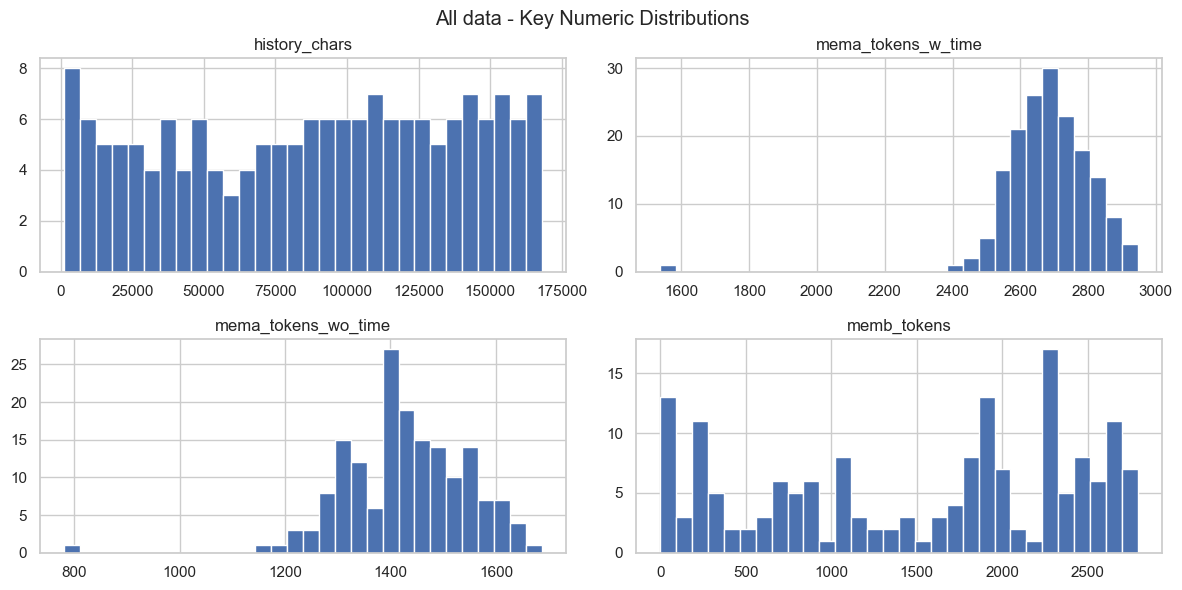

== 筛选后数据 - 关键字段直方图 ==
该组图展示历史长度与 token 计数在当前数据集的分布，帮助识别常见规模。


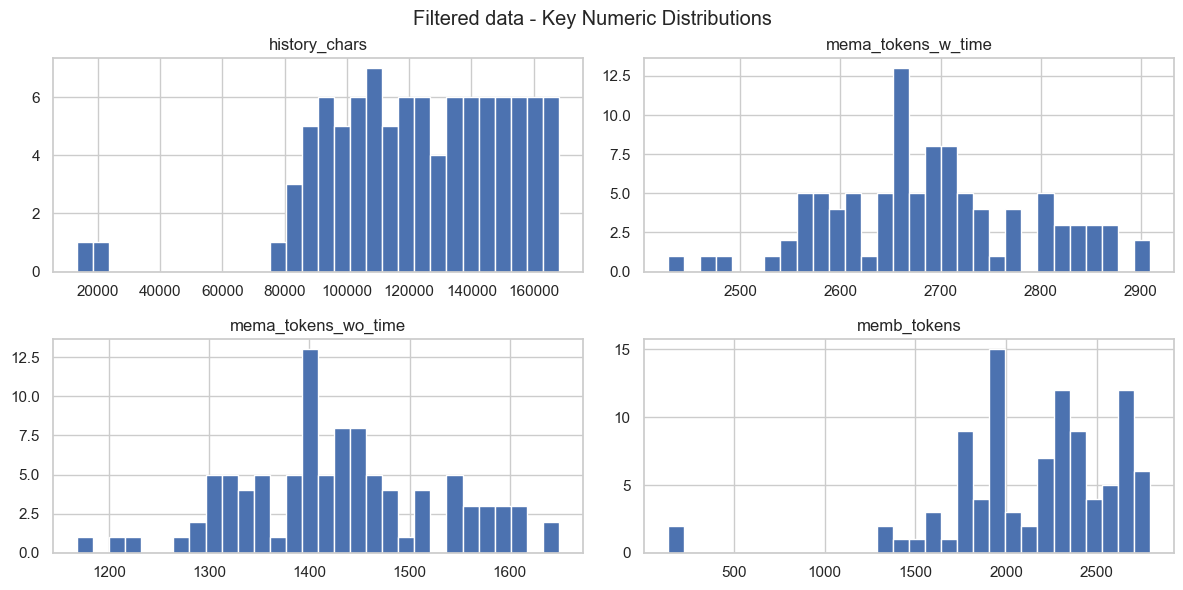

In [6]:
# 该单元绘制直方图
cols = ['history_chars', 'mema_tokens_w_time', 'mema_tokens_wo_time', 'memb_tokens']
HIST_PATHS = {}
for desc, en_label, dataset in DATASET_PAIRS:
    print(f'== {desc} - 关键字段直方图 ==')
    print('该组图展示历史长度与 token 计数在当前数据集的分布，帮助识别常见规模。')
    fig, axes = plt.subplots(2, 2, figsize=(12, 6))
    axes = axes.flatten()
    for ax, column in zip(axes, cols):
        data = dataset[column].dropna()
        if data.empty:
            ax.text(0.5, 0.5, 'No data available', ha='center', va='center')
            ax.set_title(column)
            ax.set_xticks([])
            ax.set_yticks([])
            continue
        ax.hist(data, bins=30)
        ax.set_title(column)
        ax.set_xlabel('')
    fig.suptitle(f'{en_label} - Key Numeric Distributions')
    fig.tight_layout()
    fig.subplots_adjust(top=0.9)
    out_path = REPORT_ASSETS_DIR / f"hist_{en_label.replace(' ', '_').lower()}.png"
    fig.savefig(out_path, dpi=160, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    HIST_PATHS[en_label] = out_path


## Token 与历史字符比值

该单元展示每个案例中 token 数量与 history 长度的比值，比较不同策略下的 token 密度。

== 全部数据 - token 与字符比值箱线图 ==
该图比较不同策略下的每字符 token 密度，方便观察是否有过度冗余。


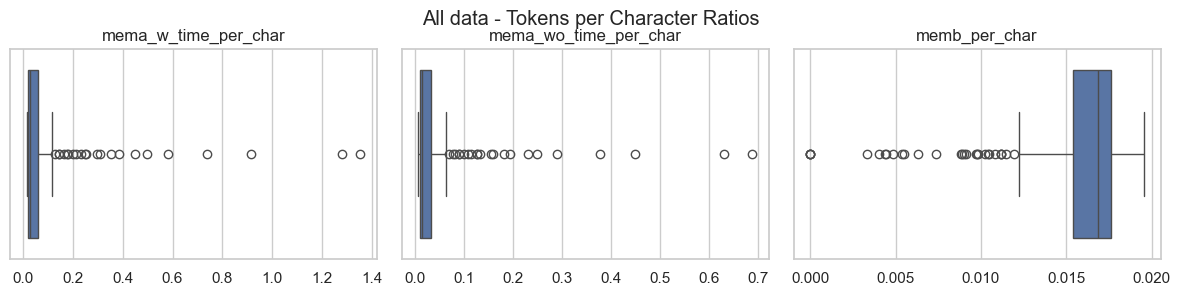

== 筛选后数据 - token 与字符比值箱线图 ==
该图比较不同策略下的每字符 token 密度，方便观察是否有过度冗余。


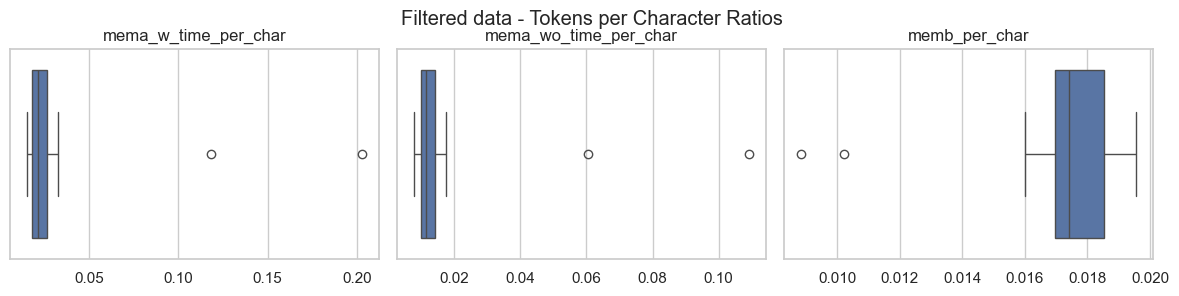

In [7]:
# 该单元绘制 token/字符箱线图
ratio_cols = ['mema_w_time_per_char', 'mema_wo_time_per_char', 'memb_per_char']
for desc, en_label, dataset in DATASET_PAIRS:
    print(f'== {desc} - token 与字符比值箱线图 ==')
    print('该图比较不同策略下的每字符 token 密度，方便观察是否有过度冗余。')
    fig, axes = plt.subplots(1, len(ratio_cols), figsize=(12, 3), sharey=False)
    axes = np.atleast_1d(axes)
    for ax, column in zip(axes, ratio_cols):
        data = dataset[column].dropna()
        if data.empty:
            ax.text(0.5, 0.5, 'No data available', ha='center', va='center')
            ax.set_title(column)
            ax.set_xticks([])
            continue
        if sns:
            sns.boxplot(x=data, ax=ax)
        else:
            ax.boxplot(data, vert=False)
        ax.set_title(column)
        ax.set_xlabel('')
    fig.suptitle(f'{en_label} - Tokens per Character Ratios')
    fig.tight_layout()
    fig.subplots_adjust(top=0.85)
    plt.show()


## 胜者分布

该单元统计 judge 判定中哪一方被评为胜出，衡量总体偏向。

== 全部数据 胜者统计 ==
该图展示 judge 总体胜者的数量对比，便于快速判断整体偏向。


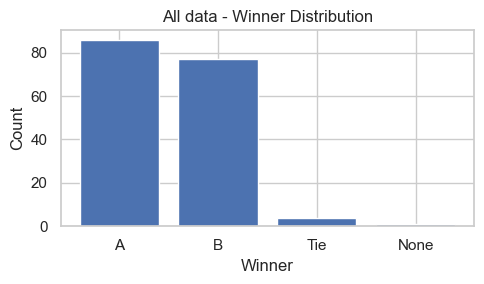

judge_overall_winner
A       86
B       77
Tie      4
None     1
Name: count, dtype: int64

== 筛选后数据 胜者统计 ==
该图展示 judge 总体胜者的数量对比，便于快速判断整体偏向。


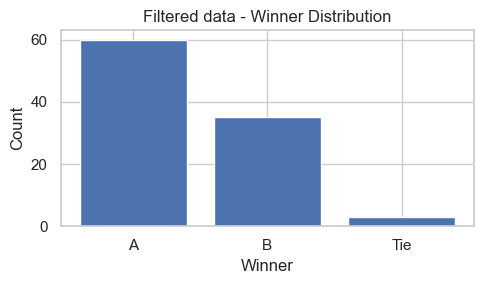

judge_overall_winner
A      60
B      35
Tie     3
Name: count, dtype: int64

In [8]:
# 该单元展示 judge_overall_winner 分布
WINNER_PATHS = {}
for desc, en_label, dataset in DATASET_PAIRS:
    print(f'== {desc} 胜者统计 ==')
    print('该图展示 judge 总体胜者的数量对比，便于快速判断整体偏向。')
    counts = dataset['judge_overall_winner'].value_counts(dropna=False)
    fig, ax = plt.subplots(figsize=(5, 3))
    if counts.empty:
        ax.text(0.5, 0.5, 'No data available', ha='center', va='center')
        ax.set_xticks([])
        ax.set_yticks([])
    else:
        ax.bar(counts.index.astype(str), counts.values)
        ax.set_xlabel('Winner')
        ax.set_ylabel('Count')
    ax.set_title(f'{en_label} - Winner Distribution')
    fig.tight_layout()
    out_path = REPORT_ASSETS_DIR / f"winner_{en_label.replace(' ', '_').lower()}.png"
    fig.savefig(out_path, dpi=160, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    WINNER_PATHS[en_label] = out_path
    display(counts)


## 各维度评分

该单元对 Relevance/Faithfulness 等维度的 A/B 评分做箱线比较，观察平均水平。

== 全部数据 - 各维度得分 ==
该图以柱状图+误差条展示各维度 A/B 的均值与波动，便于比较整体水平。
== 筛选后数据 - 各维度得分 ==
该图以柱状图+误差条展示各维度 A/B 的均值与波动，便于比较整体水平。


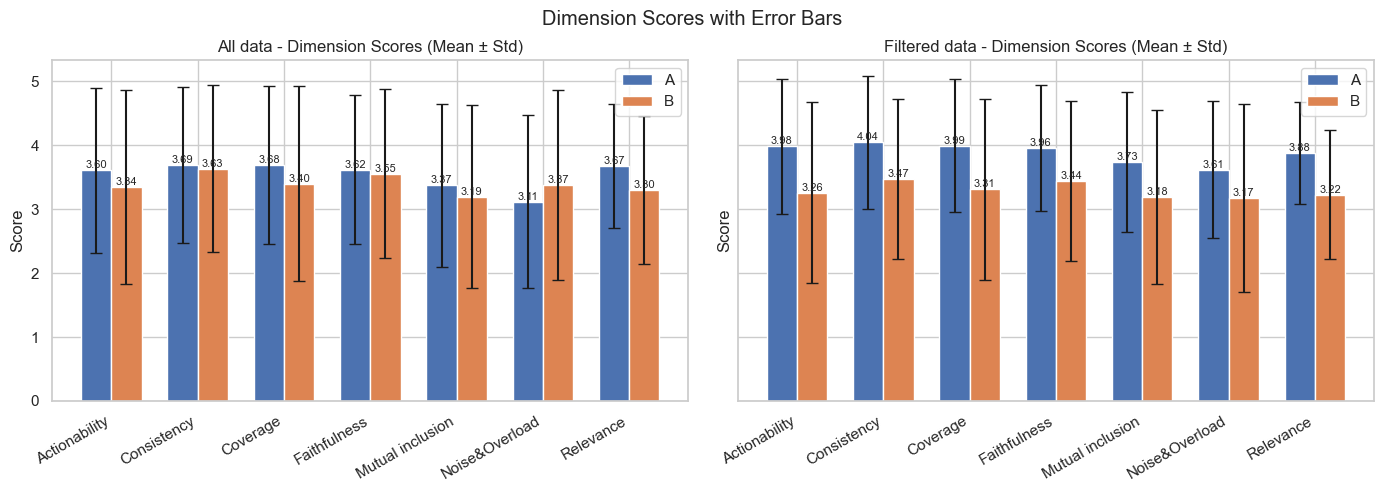

== 全部数据 - mean scores ==


side,A,B
dimension,,
Actionability,3.604790,3.343558
Consistency,3.688623,3.631902
Coverage,3.682635,3.398773
Faithfulness,3.616766,3.548780
Mutual inclusion,3.371257,3.189024
Noise&Overload,3.113772,3.374233
Relevance,3.670659,3.298780


== 筛选后数据 - mean scores ==


side,A,B
dimension,,
Actionability,3.979592,3.255102
Consistency,4.040816,3.469388
Coverage,3.989796,3.306122
Faithfulness,3.959184,3.438776
Mutual inclusion,3.734694,3.183673
Noise&Overload,3.612245,3.173469
Relevance,3.877551,3.224490


In [9]:
# 该单元构造并绘图各维度得分
def extract_scores(dataset):
    entries = []
    for _, row in dataset.iterrows():
        scores = row.get('judge', {}).get('scores', {}) if isinstance(row.get('judge'), dict) else {}
        for dimension, payload in scores.items():
            for side in ['A', 'B']:
                score = payload.get(side, {}).get('score_1_5') if isinstance(payload.get(side), dict) else None
                entries.append({
                    'idx': row.get('idx'),
                    'dimension': dimension,
                    'side': side,
                    'score': score,
                })
    return pd.DataFrame(entries)

score_collections = []
for desc, en_label, dataset in DATASET_PAIRS:
    level_df = extract_scores(dataset)
    print(f'== {desc} - 各维度得分 ==')
    print('该图以柱状图+误差条展示各维度 A/B 的均值与波动，便于比较整体水平。')
    score_collections.append((desc, en_label, level_df))

fig, axes = plt.subplots(1, max(1, len(score_collections)), figsize=(14, 5), sharey=True)
axes = np.atleast_1d(axes)
for (desc, en_label, level_df), ax in zip(score_collections, axes):
    if level_df.empty:
        ax.text(0.5, 0.5, 'No score data', ha='center', va='center')
        ax.set_title(f'{en_label} - Dimension Scores')
        ax.set_xticks([])
        ax.set_yticks([])
        continue
    summary = level_df.groupby(['dimension', 'side'])['score'].agg(['mean', 'std']).reset_index()
    dimensions = summary['dimension'].unique().tolist()
    sides = ['A', 'B']
    x = np.arange(len(dimensions))
    width = 0.35
    for i, side in enumerate(sides):
        side_data = summary[summary['side'] == side]
        means = [side_data[side_data['dimension'] == d]['mean'].values[0] if not side_data[side_data['dimension'] == d].empty else np.nan for d in dimensions]
        stds = [side_data[side_data['dimension'] == d]['std'].values[0] if not side_data[side_data['dimension'] == d].empty else 0 for d in dimensions]
        ax.bar(x + (i - 0.5) * width, means, width, yerr=stds, capsize=4, label=side)
        for xi, mean in zip(x + (i - 0.5) * width, means):
            if np.isnan(mean):
                continue
            ax.text(xi, mean, f'{mean:.2f}', ha='center', va='bottom', fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(dimensions, rotation=30, ha='right')
    ax.set_title(f'{en_label} - Dimension Scores (Mean ± Std)')
    ax.set_ylabel('Score')
    ax.legend(loc='upper right')
fig.suptitle('Dimension Scores with Error Bars')
fig.tight_layout()
fig.subplots_adjust(top=0.88)
SCORE_PATH = REPORT_ASSETS_DIR / 'dimension_scores.png'
fig.savefig(SCORE_PATH, dpi=160, bbox_inches='tight')
plt.show()
plt.close(fig)

for desc, en_label, level_df in score_collections:
    if level_df.empty:
        continue
    print(f'== {desc} - mean scores ==')
    display(level_df.groupby(['dimension', 'side'])['score'].mean().unstack())


## Item Audit 标签分布

该单元统计 A/B 的 item_audit 中标签数量，观察标注倾向。

In [10]:
# 该单元统计 item_audit 标签
def extract_labels(dataset):
    rows = []
    for _, row in dataset.iterrows():
        item_audit = row.get('judge', {}).get('item_audit', {})
        for side in ['A', 'B']:
            for entry in item_audit.get(side, []):
                rows.append({'idx': row.get('idx'), 'side': side, 'label': entry.get('label')})
    return pd.DataFrame(rows)

for title, dataset in [('全部数据', df), ('筛选后数据', df_filtered)]:
    label_df = extract_labels(dataset)
    print(f'== {title} item_audit 标签计数 ==')
    if label_df.empty:
        print('无 label 数据')
        continue
    display(label_df['label'].value_counts())

== 全部数据 item_audit 标签计数 ==


label
Supported & Useful              3000
Unsupported / Not Verifiable     511
Supported but Not Useful         341
Supported & Not Useful            31
Support3 but Not Useful            1
Support but Not Useful             1
Name: count, dtype: int64

== 筛选后数据 item_audit 标签计数 ==


label
Supported & Useful              1826
Unsupported / Not Verifiable     328
Supported but Not Useful         250
Name: count, dtype: int64

## Item Audit 标签按 A/B 比较

该单元以柱状图展示各标签在 A/B 之间的分布差异。

== 全部数据 - item_audit 标签按侧展示 ==
该图展示各标签在 A/B 之间出现频次的差异，有助于判断偏向。
== 筛选后数据 - item_audit 标签按侧展示 ==
该图展示各标签在 A/B 之间出现频次的差异，有助于判断偏向。


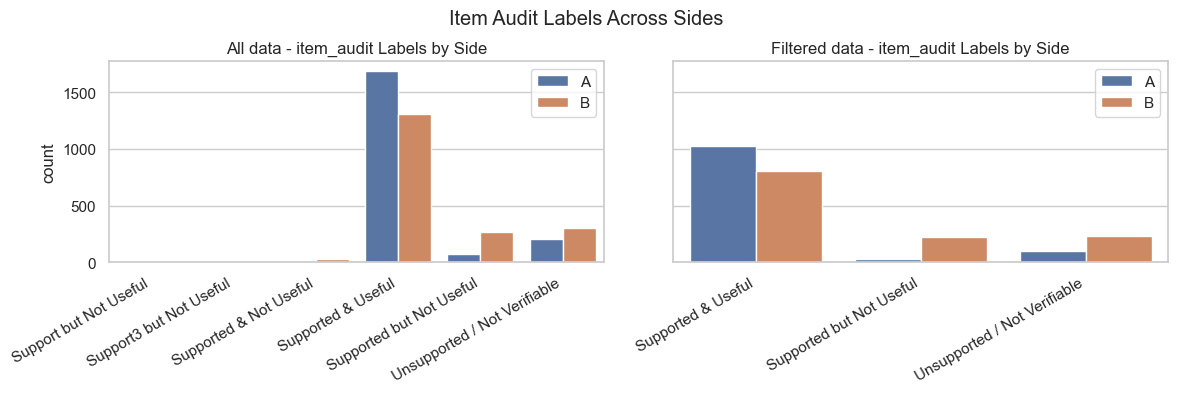

label
Supported & Useful              3000
Unsupported / Not Verifiable     511
Supported but Not Useful         341
Supported & Not Useful            31
Support3 but Not Useful            1
Support but Not Useful             1
Name: count, dtype: int64

label
Supported & Useful              1826
Unsupported / Not Verifiable     328
Supported but Not Useful         250
Name: count, dtype: int64

In [11]:
# 该单元绘制 item_audit 标签柱状图
label_collections = []
for desc, en_label, dataset in DATASET_PAIRS:
    label_df = extract_labels(dataset)
    print(f'== {desc} - item_audit 标签按侧展示 ==')
    print('该图展示各标签在 A/B 之间出现频次的差异，有助于判断偏向。')
    label_collections.append((desc, en_label, label_df))

fig, axes = plt.subplots(1, max(1, len(label_collections)), figsize=(12, 4), sharey=True)
axes = np.atleast_1d(axes)
for (desc, en_label, label_df), ax in zip(label_collections, axes):
    if label_df.empty:
        ax.text(0.5, 0.5, 'No label data', ha='center', va='center')
        ax.set_title(f'{en_label} - item_audit Labels by Side')
        ax.set_xticks([])
        ax.set_yticks([])
        continue
    counts = label_df.groupby(['side', 'label']).size().reset_index(name='count')
    if counts.empty:
        ax.text(0.5, 0.5, 'No label counts', ha='center', va='center')
        ax.set_title(f'{en_label} - item_audit Labels by Side')
        ax.set_xticks([])
        ax.set_yticks([])
        continue
    if sns:
        sns.barplot(data=counts, x='label', y='count', hue='side', ax=ax)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
        ax.legend(loc='upper right')
    else:
        pivot = counts.pivot(index='label', columns='side', values='count').fillna(0)
        pivot.plot(kind='bar', ax=ax)
        ax.legend(loc='upper right')
    ax.set_title(f'{en_label} - item_audit Labels by Side')
    ax.set_xlabel('')
fig.suptitle('Item Audit Labels Across Sides')
fig.tight_layout()
fig.subplots_adjust(top=0.85)
plt.show()

for desc, en_label, label_df in label_collections:
    if label_df.empty:
        continue
    display(label_df['label'].value_counts())


## 关键点数量分布

该单元统计 judge 中 critical_points 的数量，判断细节丰富程度。

== 全部数据 - critical_points_count ==
该图展示 judge 中关键点数量的分布，反映信息密度。
== 筛选后数据 - critical_points_count ==
该图展示 judge 中关键点数量的分布，反映信息密度。


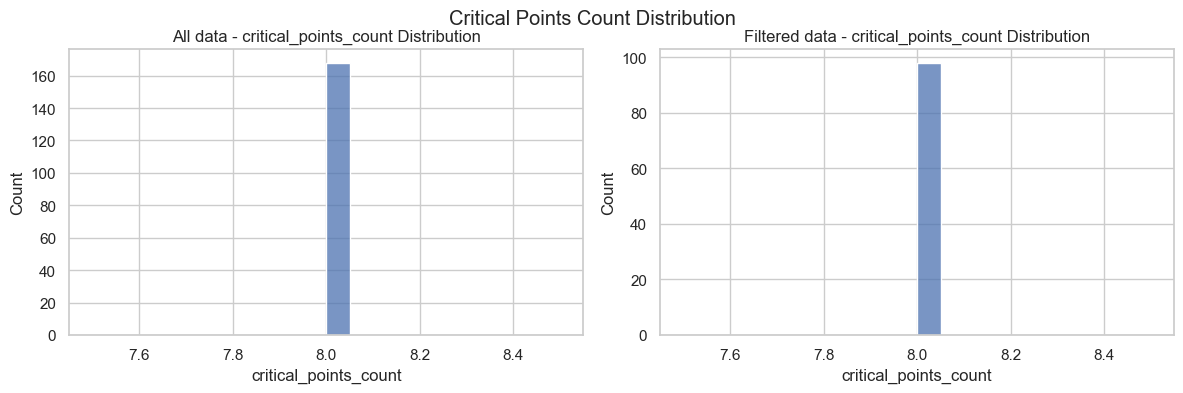

== 全部数据 - critical_points summary ==


count    168.0
mean       8.0
std        0.0
min        8.0
25%        8.0
50%        8.0
75%        8.0
max        8.0
Name: critical_points_count, dtype: float64

== 筛选后数据 - critical_points summary ==


count    98.0
mean      8.0
std       0.0
min       8.0
25%       8.0
50%       8.0
75%       8.0
max       8.0
Name: critical_points_count, dtype: float64

In [12]:
# 该单元绘制 critical_points 数直方图
fig, axes = plt.subplots(1, max(1, len(DATASET_PAIRS)), figsize=(12, 4))
axes = np.atleast_1d(axes)
for (desc, en_label, dataset), ax in zip(DATASET_PAIRS, axes):
    print(f'== {desc} - critical_points_count ==')
    print('该图展示 judge 中关键点数量的分布，反映信息密度。')
    data = dataset['critical_points_count'].dropna()
    if data.empty:
        ax.text(0.5, 0.5, 'No data available', ha='center', va='center')
        ax.set_title(f'{en_label} - critical_points_count Distribution')
        ax.set_xticks([])
        ax.set_yticks([])
        continue
    if sns:
        sns.histplot(data, bins=20, kde=False, ax=ax)
    else:
        ax.hist(data, bins=20)
    ax.set_title(f'{en_label} - critical_points_count Distribution')
fig.suptitle('Critical Points Count Distribution')
fig.tight_layout()
fig.subplots_adjust(top=0.88)
plt.show()

for desc, en_label, dataset in DATASET_PAIRS:
    print(f'== {desc} - critical_points summary ==')
    display(dataset['critical_points_count'].describe())


## Useless Ratio 简介

该单元对 A/B 的 useless_ratio 进行描述，观察是否存在大量空洞信息。

In [13]:
# 该单元展示 useless_ratio 描述
for title, dataset in [('全部数据', df), ('筛选后数据', df_filtered)]:
    print(f'== {title} useless_ratio ==')
    display(dataset[['useless_ratio_A', 'useless_ratio_B']].describe().T)


== 全部数据 useless_ratio ==


,count,mean,std,min,25%,50%,75%,max
useless_ratio_A,168.0,25.169643,16.918688,0.0,13.0,25.0,33.0,100.0
useless_ratio_B,161.0,30.254658,24.984002,0.0,12.0,25.0,38.0,100.0


== 筛选后数据 useless_ratio ==


,count,mean,std,min,25%,50%,75%,max
useless_ratio_A,98.0,23.061224,15.056469,0.0,13.0,25.0,30.0,100.0
useless_ratio_B,93.0,31.833333,25.558898,0.0,12.0,25.0,40.0,100.0


## 数值相关性

该单元基于数值列的 Pearson 相关系数，观察 token、history 等字段之间的关系。

== 全部数据 相关性热力图 ==
该图展示数值字段之间的 Pearson 相关系数，辅助判断字段间关系。
== 筛选后数据 相关性热力图 ==
该图展示数值字段之间的 Pearson 相关系数，辅助判断字段间关系。


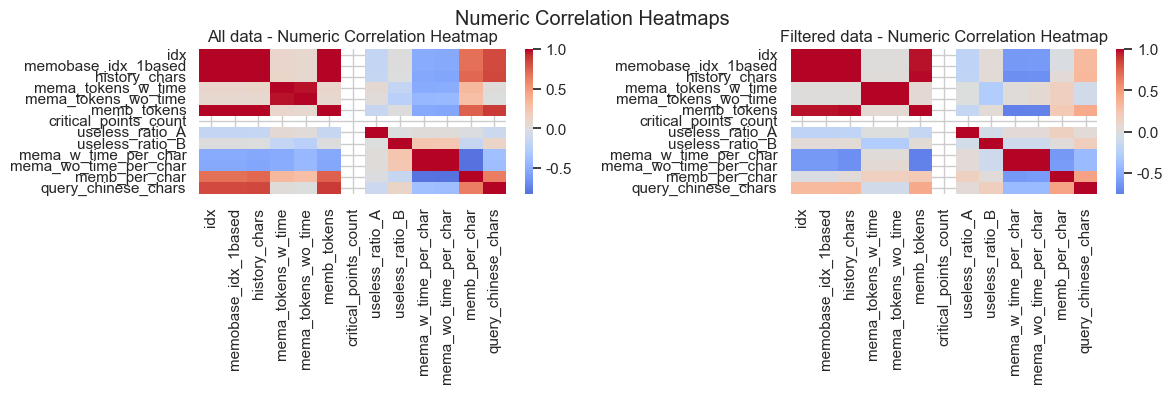

In [14]:
# 该单元绘制相关矩阵热力图
fig, axes = plt.subplots(1, max(1, len(DATASET_PAIRS)), figsize=(len(DATASET_PAIRS) * 6, 4))
axes = np.atleast_1d(axes)
for (desc, en_label, dataset), ax in zip(DATASET_PAIRS, axes):
    num_df = dataset.select_dtypes(include=[np.number])
    print(f'== {desc} 相关性热力图 ==')
    print('该图展示数值字段之间的 Pearson 相关系数，辅助判断字段间关系。')
    if num_df.shape[1] < 2:
        ax.text(0.5, 0.5, 'Insufficient numeric columns', ha='center', va='center')
        ax.set_title(f'{en_label} - Numeric Correlation Heatmap')
        ax.set_xticks([])
        ax.set_yticks([])
        continue
    corr = num_df.corr(numeric_only=True)
    if sns:
        sns.heatmap(corr, cmap='coolwarm', center=0, ax=ax)
    else:
        im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
        fig.colorbar(im, ax=ax)
        ax.set_xticks(range(len(corr.columns)))
        ax.set_xticklabels(corr.columns, rotation=90)
        ax.set_yticks(range(len(corr.columns)))
        ax.set_yticklabels(corr.columns)
    ax.set_title(f'{en_label} - Numeric Correlation Heatmap')
fig.suptitle('Numeric Correlation Heatmaps')
fig.tight_layout()
fig.subplots_adjust(top=0.88)
plt.show()


## 来源文件差异

该单元展示不同源文件在主要字段上的箱线图，比较两个原始文件是否存在偏差。

== 全部数据 - 来源文件箱线图 ==
该组箱线图比较不同来源文件在关键字段上的分布差异。


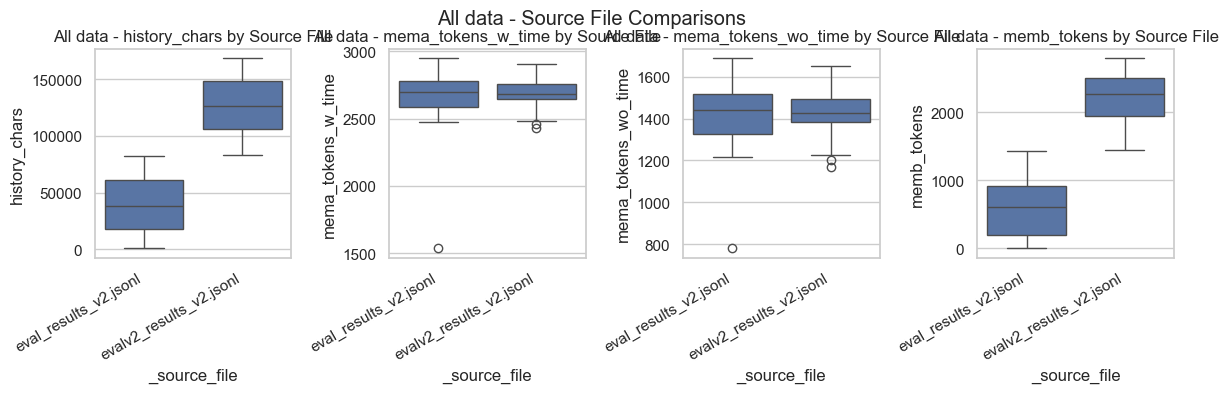

== 筛选后数据 - 来源文件箱线图 ==
该组箱线图比较不同来源文件在关键字段上的分布差异。


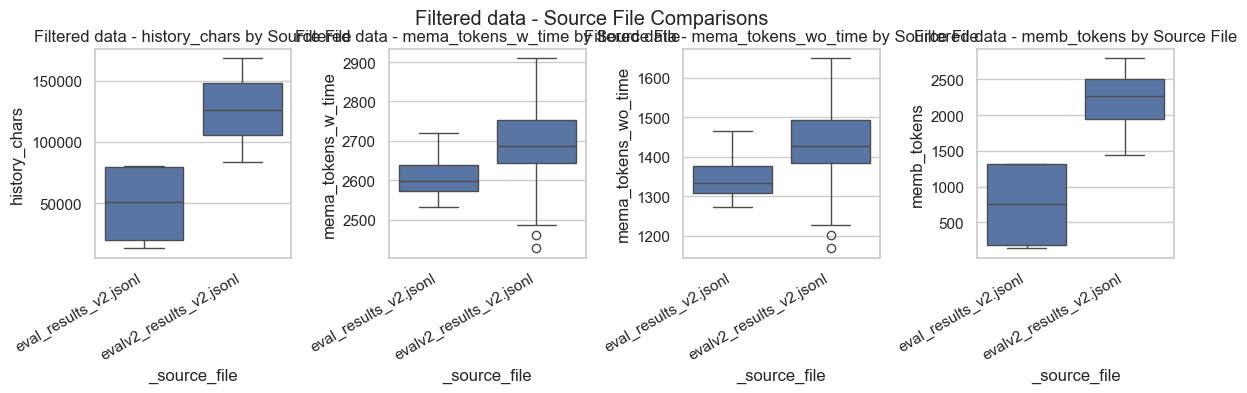

In [15]:
# 该单元绘制不同来源文件的箱线图
columns = ['history_chars', 'mema_tokens_w_time', 'mema_tokens_wo_time', 'memb_tokens']
for desc, en_label, dataset in DATASET_PAIRS:
    print(f'== {desc} - 来源文件箱线图 ==')
    print('该组箱线图比较不同来源文件在关键字段上的分布差异。')
    if dataset.empty:
        print('数据为空，跳过。')
        continue
    fig, axes = plt.subplots(1, len(columns), figsize=(len(columns) * 3, 4), sharey=False)
    axes = np.atleast_1d(axes)
    for ax, column in zip(axes, columns):
        if dataset[column].dropna().empty or dataset['_source_file'].dropna().empty:
            ax.text(0.5, 0.5, 'Missing data', ha='center', va='center')
            ax.set_title(column)
            ax.set_xticks([])
            ax.set_yticks([])
            continue
        if sns:
            sns.boxplot(data=dataset, x='_source_file', y=column, ax=ax)
            ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
        else:
            pivot = dataset.groupby('_source_file')[column].apply(list)
            box_data = [pivot.values[i] for i in range(len(pivot))]
            ax.boxplot(box_data)
            ax.set_xticklabels(pivot.index, rotation=30, ha='right')
        ax.set_title(f'{en_label} - {column} by Source File')
    fig.suptitle(f'{en_label} - Source File Comparisons')
    fig.tight_layout()
    fig.subplots_adjust(top=0.88)
    plt.show()


## 历史字符极端值

该单元列出 history_chars 最高的 5 条记录，以便人工复核是否有特别长的上下文。

In [16]:
# 该单元展示 history_chars 最大值案例
print('== 全部数据 top5 history_chars ==')
display(df.nlargest(5, 'history_chars')[['idx', '_source_file', 'history_chars', 'mema_tokens_w_time', 'mema_tokens_wo_time', 'memb_tokens']])
print('== 筛选后数据 top5 history_chars ==')
display(df_filtered.nlargest(5, 'history_chars')[['idx', '_source_file', 'history_chars', 'mema_tokens_w_time', 'mema_tokens_wo_time', 'memb_tokens']])

== 全部数据 top5 history_chars ==


,idx,_source_file,history_chars,mema_tokens_w_time,mema_tokens_wo_time,memb_tokens
164,170,evalv2_results_v2.jsonl,168056,2646,1386,2792
167,169,evalv2_results_v2.jsonl,167086,2564,1304,2699
166,168,evalv2_results_v2.jsonl,166136,2826,1566,2707
163,167,evalv2_results_v2.jsonl,165070,2666,1406,2641
165,166,evalv2_results_v2.jsonl,164334,2654,1394,2660


== 筛选后数据 top5 history_chars ==


,idx,_source_file,history_chars,mema_tokens_w_time,mema_tokens_wo_time,memb_tokens
164,170,evalv2_results_v2.jsonl,168056,2646,1386,2792
167,169,evalv2_results_v2.jsonl,167086,2564,1304,2699
166,168,evalv2_results_v2.jsonl,166136,2826,1566,2707
163,167,evalv2_results_v2.jsonl,165070,2666,1406,2641
165,166,evalv2_results_v2.jsonl,164334,2654,1394,2660


## 额外分析：胜者与来源/长度关系

该部分补充从来源文件与 query 长度角度观察胜者分布。

== 全部数据 - 来源文件胜者分布 ==
该图比较不同来源文件中 A/B 胜者数量差异。


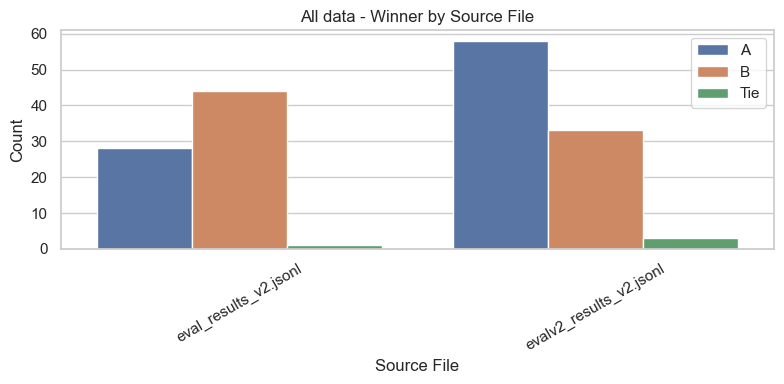

== 全部数据 - query 中文长度分桶胜者分布 ==
该图观察 query 长度分桶下的胜者分布变化。


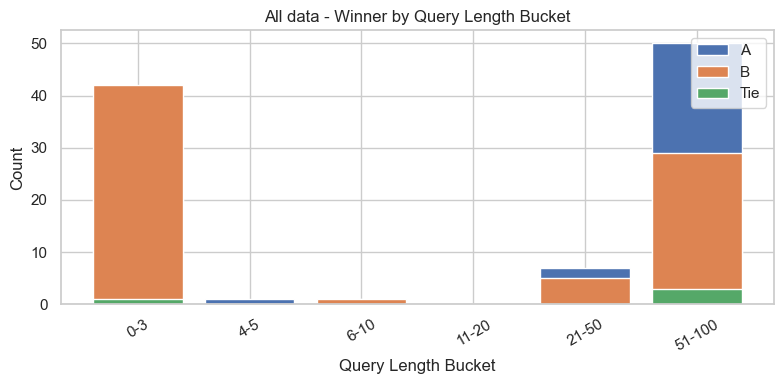

== 筛选后数据 - 来源文件胜者分布 ==
该图比较不同来源文件中 A/B 胜者数量差异。


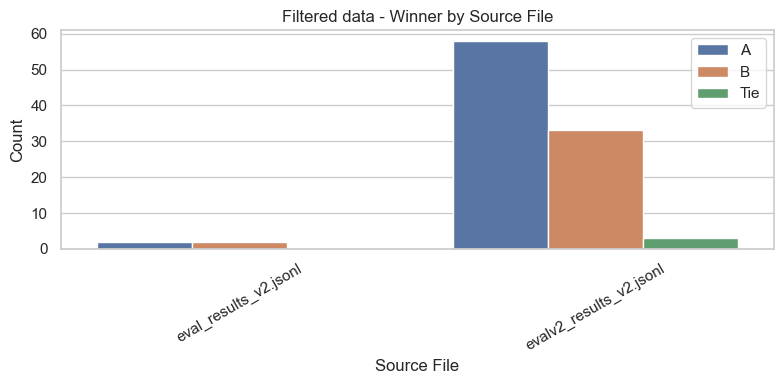

== 筛选后数据 - query 中文长度分桶胜者分布 ==
该图观察 query 长度分桶下的胜者分布变化。


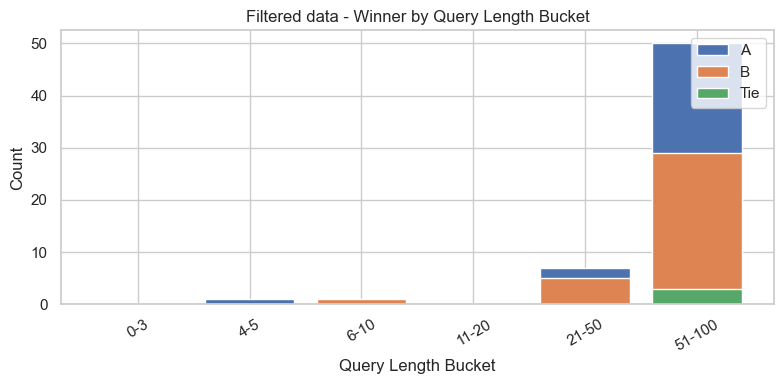

In [17]:
# 该单元补充胜者在来源文件与 query 长度分组下的对比
for desc, en_label, dataset in DATASET_PAIRS:
    print(f'== {desc} - 来源文件胜者分布 ==')
    print('该图比较不同来源文件中 A/B 胜者数量差异。')
    if dataset.empty:
        print('数据为空，跳过。')
        continue
    grouped = dataset.groupby(['_source_file', 'judge_overall_winner']).size().reset_index(name='count')
    if grouped.empty:
        print('无分组数据，跳过。')
        continue
    fig, ax = plt.subplots(figsize=(8, 4))
    if sns:
        sns.barplot(data=grouped, x='_source_file', y='count', hue='judge_overall_winner', ax=ax)
    else:
        for winner in grouped['judge_overall_winner'].unique():
            sub = grouped[grouped['judge_overall_winner'] == winner]
            ax.bar(sub['_source_file'], sub['count'], label=str(winner))
    ax.set_title(f'{en_label} - Winner by Source File')
    ax.set_xlabel('Source File')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(loc='upper right')
    fig.tight_layout()
    plt.show()
    plt.close(fig)

    print(f'== {desc} - query 中文长度分桶胜者分布 ==')
    print('该图观察 query 长度分桶下的胜者分布变化。')
    if 'query' not in dataset.columns:
        print('缺少 query 字段，跳过。')
        continue
    length = dataset['query'].apply(chinese_char_count)
    bins = [0, 3, 5, 10, 20, 50, 100]
    labels = ['0-3', '4-5', '6-10', '11-20', '21-50', '51-100']
    binned = pd.cut(length, bins=bins, labels=labels, right=True, include_lowest=True)
    bucket_df = pd.DataFrame({'bucket': binned, 'winner': dataset['judge_overall_winner']})
    bucket_counts = bucket_df.groupby(['bucket', 'winner']).size().reset_index(name='count')
    if bucket_counts.empty:
        print('无分桶数据，跳过。')
        continue
    fig, ax = plt.subplots(figsize=(8, 4))
    for winner in bucket_counts['winner'].dropna().unique():
        sub = bucket_counts[bucket_counts['winner'] == winner]
        ax.bar(sub['bucket'].astype(str), sub['count'], label=str(winner))
    ax.set_title(f'{en_label} - Winner by Query Length Bucket')
    ax.set_xlabel('Query Length Bucket')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(loc='upper right')
    fig.tight_layout()
    out_path = REPORT_ASSETS_DIR / f"winner_by_query_bucket_{en_label.replace(' ', '_').lower()}.png"
    fig.savefig(out_path, dpi=160, bbox_inches='tight')
    plt.show()
    plt.close(fig)


In [18]:
# 该单元生成本次运行的 report.md（带图）
import time

if 'RUN_ID' not in globals():
    RUN_ID = time.strftime('%Y%m%d_%H%M%S')
if 'REPORTS_DIR' not in globals():
    REPORTS_DIR = BASE_DIR / 'reports'
    REPORTS_DIR.mkdir(exist_ok=True)
if 'REPORT_ASSETS_DIR' not in globals():
    REPORT_ASSETS_DIR = REPORTS_DIR / f'report_assets_{RUN_ID}'
    REPORT_ASSETS_DIR.mkdir(exist_ok=True)

if 'input_label' not in globals():
    try:
        input_label = MERGED_JSONL.name
    except Exception:
        input_label = 'merged'

if 'report_summary' not in globals():
    if 'df' in globals() and 'df_filtered' in globals():
        report_summary = {
            'input_label': input_label,
            'total_rows': len(df),
            'filtered_rows': len(df_filtered),
            'low_info_count': None,
            'short_query_count': None,
        }
    else:
        raise RuntimeError('Missing report_summary and dataframes; please run the data loading cell first.')

missing = []
if 'HIST_PATHS' not in globals():
    missing.append('HIST_PATHS')
if 'WINNER_PATHS' not in globals():
    missing.append('WINNER_PATHS')
if 'SCORE_PATH' not in globals():
    missing.append('SCORE_PATH')

if missing:
    raise RuntimeError(f"Missing required outputs: {', '.join(missing)}. Please run the plotting cells first.")

report_name = f"report_{input_label.replace('.jsonl', '').replace('+', '_')}_{RUN_ID}.md"
report_path = REPORTS_DIR / report_name

all_hist = HIST_PATHS.get('All data')
filtered_hist = HIST_PATHS.get('Filtered data')
all_winner = WINNER_PATHS.get('All data')
filtered_winner = WINNER_PATHS.get('Filtered data')

all_bucket = REPORT_ASSETS_DIR / 'winner_by_query_bucket_all_data.png'
filtered_bucket = REPORT_ASSETS_DIR / 'winner_by_query_bucket_filtered_data.png'

report_md = f"""# Evaluation Summary ({input_label})

## 1. 数据概览
- 原始总行数：{report_summary['total_rows']}
- 筛选后行数：{report_summary['filtered_rows']}
- 低信息 query 数量：{report_summary['low_info_count']}
- 中文字符数少于 4 的条目：{report_summary['short_query_count']}

## 2. 关键字段直方图

**All data**

![All data - Key Numeric Distributions]({all_hist.relative_to(REPORTS_DIR)})

**Filtered data**

![Filtered data - Key Numeric Distributions]({filtered_hist.relative_to(REPORTS_DIR)})

## 3. 胜者统计

**All data**

![All data - Winner Distribution]({all_winner.relative_to(REPORTS_DIR)})

**Filtered data**

![Filtered data - Winner Distribution]({filtered_winner.relative_to(REPORTS_DIR)})

## 4. 各维度得分

![Dimension Scores with Error Bars]({SCORE_PATH.relative_to(REPORTS_DIR)})

## 5. query 长度分桶下的胜者分布变化

**All data**

![Winner by Query Length Bucket - All]({all_bucket.relative_to(REPORTS_DIR)})

**Filtered data**

![Winner by Query Length Bucket - Filtered]({filtered_bucket.relative_to(REPORTS_DIR)})

## 结论

"""

report_path.write_text(report_md, encoding='utf-8')
print(f"已写入报告：{report_path}")


已写入报告：reports/report_eval_merged_v2_20260105_112659.md
